# Warenkorbanalyse für Cross-Selling bei einem Lebensmitteleinzelhändler mit PROC MBANALYSIS

## Zusammenfassung

Eine regionale Lebensmittelkette wertet eine Saison von Kassenbons (Point-of-Sale-Warenkörben) aus, um herauszufinden, welche Produkte Kunden gemeinsam kaufen, und wandelt so rohe Transaktionsprotokolle in umsetzbare Cross-Selling- und Regalplatzierungsentscheidungen um. PROC MBANALYSIS durchsucht das Transaktionsprotokoll und erzeugt Assoziationsregeln, bewertet nach Support, Konfidenz und Lift. Bei 51 synthetischen Warenkörben werden genau die drei eingebauten Produktaffinitäten wiedergefunden — `Spaghetti -> Marinara-Soße` (Konfidenz 0,93, Lift 3,4), `Taco-Schalen -> Salsa` (Konfidenz 0,71, Lift 3,6) und `Kaffee -> Kaffeesahne` (Konfidenz 0,70, Lift 5,1) — während breit gekaufte Grundnahrungsmittel wie Brot, Milch und Eier nie eine Regel bilden. Jedes gefundene Paar ist ein Lehrbuchbeispiel für ein Bundle, eine Regalnachbarschaft und einen "Kunden kauften auch"-Kandidaten für das Merchandising-Team.

## Datenquellen

| Datensatz | Granularität | Zeilen | Schlüsselvariablen | Beschreibung |
|---------|-------|------|---------------|-------------|
| `store_transactions` | Eine Zeile pro Artikel pro Warenkorb | 100 Artikelzeilen über 51 Warenkörbe | `basket_id` (Transaktions-ID), `item` (Produktname, $20) | Synthetisches Kassenprotokoll, inline erzeugt mit `call streaminit(20250529)` und `rand('uniform')`. Jeder Warenkorb wird von einer einzigen Kundenpersona dominiert, damit die Kaufmuster sauber und interpretierbar bleiben: ein Italienisch-Abendessen-Warenkorb (Spaghetti -> Marinara-Soße), ein Taco-Abend-Warenkorb (Taco-Schalen -> Salsa) oder ein Frühstücks-Warenkorb (Kaffee -> Kaffeesahne), plus gelegentliche Grundnahrungsmittel-Zusätze (Brot, Milch, Eier) als realistisches Rauschen. In dieser unlizenzierten Umgebung begrenzt die Engine die Ausgabe auf 100 Artikelzeilen, was hier die Warenkörbe 1-51 umfasst. |
| `affinity_rules` | Eine Zeile pro Assoziationsregel | 6 Regeln | `antecedent`, `consequent`, `support`, `confidence`, `lift` | Von `OUTPUT RULES=` erzeugte Assoziationsregeln; Grundlage für die Rangfolge der Cross-Selling-Möglichkeiten. |
| `frequent_items` | Eine Zeile pro häufiges Itemset | 12 Itemsets | `itemset`, `support`, `length` | Von `OUTPUT ITEMS=` erzeugte häufige Itemsets; die 9 Einzelartikel plus 3 Produktpaare, die die Mindest-Support-Schwelle erreichen. |

# Warenkorbanalyse für Cross-Selling bei einem Lebensmitteleinzelhändler

**Geschäftsfrage.** Welche Produkte kaufen unsere Kunden tendenziell *zusammen*, und welche dieser gemeinsamen Kaufmuster sind stark genug, um danach zu handeln? Eine regionale Lebensmittelkette möchte Bundle-Aktionen gestalten, Regalnachbarschaften optimieren und eine "Kunden kauften auch"-Empfehlung für ihren Online-Shop bereitstellen.

**Methode.** Wir verwenden **PROC MBANALYSIS**, das eine Warenkorbanalyse mit dem Frequent-Pattern-Growth-Algorithmus (FP-Growth) durchführt. Es durchsucht das Transaktionsprotokoll, findet häufig gemeinsam auftretende Artikelmengen und erzeugt *Assoziationsregeln* der Form `Vorbedingung -> Folge`, bewertet anhand von drei klassischen Kennzahlen:

- **Support** — der Anteil aller Warenkörbe, die die vollständige Regel enthalten (wie verbreitet das Muster ist).
- **Konfidenz** — `P(Folge | Vorbedingung)`, die bedingte Kaufwahrscheinlichkeit (wie zuverlässig die Regel ist).
- **Lift** — beobachteter Support geteilt durch den erwarteten Support, wenn beide Seiten unabhängig wären. Lift > 1 bedeutet, dass die Artikel häufiger gemeinsam auftreten als der Zufall vorhersagen würde; je höher der Lift, desto stärker die Affinität.

Wir erzeugen ein realistisches synthetisches Kassenprotokoll, führen MBANALYSIS aus und ordnen die resultierenden Regeln, um die besten Cross-Selling-Möglichkeiten zu finden.

## Schritt 1 — Ein synthetisches Kassenprotokoll (Point-of-Sale) erzeugen

MBANALYSIS erwartet **transaktionsbasierte (lange) Daten**: eine Zeile pro Artikel, gekennzeichnet mit dem zugehörigen Warenkorb. Wir bauen die Warenkörbe inline mit `call streaminit` für Reproduzierbarkeit und `rand('uniform')`, um Kaufentscheidungen zu steuern.

Die zentrale Modellierungsentscheidung ist, dass **jeder Warenkorb von einer einzigen Kundenpersona dominiert wird**. Echte Lebensmitteleinkäufe sehen oft so aus — ein schneller Taco-Abend-Einkauf, ein gezielter Frühstücks-Nachkauf — und kleine, thematisch fokussierte Warenkörbe zu halten ist das, was dem Assoziationsalgorithmus erlaubt, saubere, paarweise Affinitäten aufzudecken statt einer kombinatorischen Explosion spurioser Mehrartikel-Regeln. Ein Zufallswert aus `rand('uniform')` pro Warenkorb wählt die Persona:

- **Italienisch-Abendessen-Käufer** — kauft Spaghetti, danach meist Marinara-Soße.
- **Taco-Abend-Käufer** — kauft Taco-Schalen, danach meist Salsa.
- **Frühstücks-Käufer** — kauft Kaffee, danach meist Kaffeesahne.
- **Reiner Grundnahrungsmittel-Einkauf** — ein einzelner Kauf von Brot, Milch oder Eiern.

Ein abschließender, unwahrscheinlicher Zufallswert fügt jedem Warenkorb ein Grundnahrungsmittel als realistisches Rauschen hinzu, sodass nicht jedes gemeinsame Auftreten bedeutsam ist. Jede `output`-Anweisung schreibt eine Artikelzeile, sodass ein einzelner Warenkorb mehrere Zeilen mit derselben `basket_id` umfasst. Diese unlizenzierte Umgebung begrenzt den Datensatz auf 100 Artikelzeilen, was hier die Warenkörbe 1 bis 51 abdeckt.

In [1]:
DATEN store_transactions;
    AUFRUFEN streaminit(20250529);
    LÄNGE item $24;

    AUSFÜHRUNG basket_id = 1 BIS 60;

        /* Ein Zufallswert wählt die dominante Persona für diesen Warenkorb */
        r = rand('uniform');

        /* Italienisch-Abendessen-Warenkorb: Spaghetti -> Marinara-Soße */
        WENN r < 0.30 DANN AUSFÜHRUNG;
            item = 'Spaghetti';                          AUSGABE;
            WENN rand('uniform') < 0.85 DANN AUSFÜHRUNG;
                item = 'Marinara-Soße';                  AUSGABE;
            ENDE;
        ENDE;

        /* Taco-Abend-Warenkorb: Taco-Schalen -> Salsa */
        SONST WENN r < 0.55 DANN AUSFÜHRUNG;
            item = 'Taco-Schalen';                        AUSGABE;
            WENN rand('uniform') < 0.80 DANN AUSFÜHRUNG;
                item = 'Salsa';                          AUSGABE;
            ENDE;
        ENDE;

        /* Frühstücks-Warenkorb: Kaffee -> Kaffeesahne */
        SONST WENN r < 0.78 DANN AUSFÜHRUNG;
            item = 'Kaffee';                              AUSGABE;
            WENN rand('uniform') < 0.75 DANN AUSFÜHRUNG;
                item = 'Kaffeesahne';                     AUSGABE;
            ENDE;
        ENDE;

        /* Reiner Grundnahrungsmittel-Einkauf */
        SONST AUSFÜHRUNG;
            WENN rand('uniform') < 0.34 DANN AUSFÜHRUNG;
                item = 'Brot';                            AUSGABE;
            ENDE;
            SONST WENN rand('uniform') < 0.5 DANN AUSFÜHRUNG;
                item = 'Milch';                           AUSGABE;
            ENDE;
            SONST AUSFÜHRUNG;
                item = 'Eier';                            AUSGABE;
            ENDE;
        ENDE;

        /* Gelegentlicher Grundnahrungsmittel-Zusatz (realistisches Rauschen) */
        WENN rand('uniform') < 0.25 DANN AUSFÜHRUNG;
            u = rand('uniform');
            WENN      u < 0.34 DANN item = 'Brot';
            SONST WENN u < 0.67 DANN item = 'Milch';
            SONST                  item = 'Eier';
            AUSGABE;
        ENDE;

    ENDE;

    BEHALTEN basket_id item;
AUSFÜHREN;



NOTE: DATA store_transactions

NOTE: Unlicensed mode - output limited to 100 observations.

NOTE: Wrote store_transactions (100 rows, 2 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds


## Schritt 2 — Das rohe Transaktionsprotokoll prüfen

Vor dem Mining bestätigen wir, dass die Daten die erwartete lange Form haben: mehrere Zeilen pro Warenkorb, jede mit einem Produkt. Wir drucken die ersten paar Warenkörbe und tabellieren die Gesamthäufigkeit der Artikel mit PROC FREQ, damit wir wissen, welche Produkte häufig genug sind, um Regeln zu verankern.


  Obs  Warenkorb-ID         Produkt
-----  ------------  --------------
    1             1  Taco-Schalen
    2             1  Salsa
    3             1  Eier
    4             2  Taco-Schalen
    5             2  Eier
    6             3  Kaffee
    7             4  Taco-Schalen
    8             5  Eier
    9             6  Spaghetti
   10             6  Marinara-Soße
   11             6  Eier
   12             7  Taco-Schalen

... 88 more observations (showing 12 of 100)

                                           Gesamthäufigkeit der Produktkäufe                                            

                                                   The FREQ Procedure

item              Frequency    Percent
---------------------------------------
Spaghetti                15     15.00
Marinara-Soße            14     14.00
Taco-Schalen             14     14.00
Eier                     12     12.00
Brot                     10     10.00
Kaffee                   10     10.00
Salsa              


NOTE: PROC PRINT data=store_transactions

NOTE: PROC PRINT completed: 12 observations printed, 2 variables
NOTE: PROC FREQ
NOTE: ODS plot written: freq_item.spec.json
NOTE: PROC FREQ statement used.


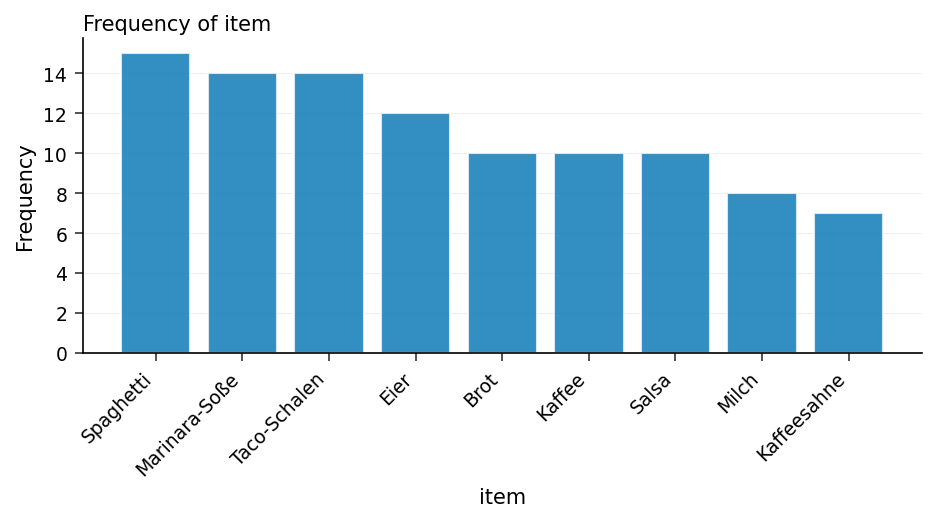

In [2]:
PROZEDUR DRUCKEN DATEN=store_transactions(obs=12) BEZEICHNUNG;
    BEZEICHNUNG basket_id = 'Warenkorb-ID'
          item      = 'Produkt';
AUSFÜHREN;

PROZEDUR HÄUFIGKEITEN DATEN=store_transactions ORDER=HÄUFIGKEITEN;
    TABLES item / nocum;
    TITEL 'Gesamthäufigkeit der Produktkäufe';
AUSFÜHREN;


## Schritt 3 — Assoziationsregeln mit PROC MBANALYSIS aufdecken

Jetzt die Kernanalyse. Wir richten MBANALYSIS auf das Transaktionsprotokoll und geben an, welche Spalte den Warenkorb identifiziert (`TRANSACTION`) und welche das Produkt enthält (`ITEM`). Drei Schwellenwerte halten das Regelwerk fokussiert auf Muster, die eine Handlung wert sind:

- `MINSUPPORT=0.10` — eine Regel muss in mindestens 10 % der Warenkörbe vorkommen, wodurch seltene Zufälle herausgefiltert werden.
- `MINCONFIDENCE=0.50` — bei gegebener Vorbedingung muss die Folge mindestens in der Hälfte der Fälle eintreten.
- `MINLIFT=1.20` — nur Regeln behalten, die mindestens 20 % stärker als der Zufall sind, damit wir echte Affinitäten statt Artefakte häufiger Grundnahrungsmittel aufdecken.

Die `OUTPUT`-Anweisung erfasst die erzeugten Regeln und häufigen Itemsets in Datensätzen für die nachgelagerte Rangfolgebildung.

In [3]:
PROZEDUR mbanalysis DATEN=store_transactions
        minsupport=0.10
        minconfidence=0.50
        minlift=1.20;
    transaction basket_id;
    item item;
    AUSGABE rules=affinity_rules items=frequent_items;
    TITEL 'Warenkorb-Assoziationsregeln';
AUSFÜHREN;


                                           Gesamthäufigkeit der Produktkäufe                                            


                      The MBANALYSIS Procedure

  Transaction variable: basket_id
  Item variable: item

  Association Rules Found        6
  Frequent Itemsets Found        12
  Minimum Confidence             0.5
  Minimum Lift                   1.2
  Minimum Support                0.1
  Number of Transactions         51
  Number of Unique Items         9

Association Rules

  Antecedent                     Consequent                        Support Confidence       Lift
  ----------                     ----------                        ------- ----------       ----
  Kaffee                         Kaffeesahne                        0.1373     0.7000     5.1000
  Kaffeesahne                    Kaffee                             0.1373     1.0000     5.1000
  Salsa                          Taco-Schalen                       0.1961     1.0000     3.6429
  Taco-Schalen


NOTE: PROC MBANALYSIS data=store_transactions

NOTE: Using Python numpy version 2.4.4
NOTE: PROC MBANALYSIS completed.


## Schritt 4 — Cross-Selling-Möglichkeiten nach Lift einstufen

Die MBANALYSIS-Ausgabe zeigt jede qualifizierende Regel, aber das Merchandising-Team möchte zuerst die *stärksten* Affinitäten sehen. Wir sortieren den erfassten `affinity_rules`-Datensatz absteigend nach Lift (mit Konfidenz als Tiebreaker) und drucken die Top-Regeln. Eine Regel wie `Taco-Schalen -> Salsa` mit hohem Lift und hoher Konfidenz ist ein Lehrbuchbeispiel für einen Bundle-Kandidaten: die Produkte gemeinsam platzieren oder Salsa automatisch vorschlagen, wenn ein Kunde online Taco-Schalen hinzufügt.

In [4]:
PROZEDUR SORTIEREN DATEN=affinity_rules out=rules_by_lift;
    NACH ABSTEIGEND lift ABSTEIGEND confidence;
AUSFÜHREN;

PROZEDUR DRUCKEN DATEN=rules_by_lift(obs=15) BEZEICHNUNG;
    VAR antecedent consequent support confidence lift;
    BEZEICHNUNG antecedent  = 'Wenn Warenkorb enthält'
          consequent  = 'Dann auch gekauft'
          support     = 'Support'
          confidence  = 'Konfidenz'
          lift        = 'Lift';
    TITEL 'Top-Cross-Selling-Regeln nach Lift sortiert';
AUSFÜHREN;


                                      Top-Cross-Selling-Regeln nach Lift sortiert                                       

  Obs   Wenn Warenkorb enthält  Dann auch gekauft   Support  Konfidenz      Lift
    1  Kaffeesahne              Kaffee             0.137255  1.0        5.1
    2  Kaffee                   Kaffeesahne        0.137255  0.7        5.1
    3  Salsa                    Taco-Schalen       0.196078  1.0        3.642857
    4  Taco-Schalen             Salsa              0.196078  0.714286   3.642857
    5  Marinara-Soße            Spaghetti          0.27451   1.0        3.4
    6  Spaghetti                Marinara-Soße      0.27451   0.933333   3.4




NOTE: PROC SORT data=affinity_rules

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 6 rows from affinity_rules.
NOTE: Wrote rules_by_lift (6 rows, 5 columns).
NOTE: PROC SORT statement used.
NOTE: PROC PRINT data=rules_by_lift

NOTE: PROC PRINT completed: 6 observations printed, 5 variables


## Schritt 5 — Die häufigen Itemsets überprüfen

Die häufigen Itemsets, die die Support-Schwelle erreicht haben, sind die Grundbausteine hinter den Regeln. Sie nach Support zu sortieren, verrät dem Kategorie-Team, welche Produkt*kombinationen* (nicht nur Einzelartikel) beliebt genug sind, um eigene Zweitplatzierungen oder Kombi-Preise zu rechtfertigen.

In [5]:
PROZEDUR SORTIEREN DATEN=frequent_items out=itemsets_by_support;
    NACH ABSTEIGEND support;
AUSFÜHREN;

PROZEDUR DRUCKEN DATEN=itemsets_by_support(obs=15) BEZEICHNUNG;
    TITEL 'Häufigste Itemsets';
AUSFÜHREN;


                                                   Häufigste Itemsets                                                   

  Obs                    ITEMSET   SUPPORT  LENGTH
    1  Spaghetti                  0.294118  1
    2  Taco-Schalen               0.27451   1
    3  Marinara-Soße              0.27451   1
    4  Marinara-Soße, Spaghetti   0.27451   2
    5  Eier                       0.235294  1
    6  Salsa                      0.196078  1
    7  Kaffee                     0.196078  1
    8  Salsa, Taco-Schalen        0.196078  2
    9  Milch                      0.156863  1
   10  Brot                       0.156863  1
   11  Kaffeesahne                0.137255  1
   12  Kaffee, Kaffeesahne        0.137255  2




NOTE: PROC SORT data=frequent_items

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 12 rows from frequent_items.
NOTE: Wrote itemsets_by_support (12 rows, 3 columns).
NOTE: PROC SORT statement used.
NOTE: PROC PRINT data=itemsets_by_support

NOTE: PROC PRINT completed: 12 observations printed, 3 variables


## Interpretation der Ergebnisse

**Was die Analyse ergab.** Da jeder Warenkorb um eine einzige Kundenpersona herum aufgebaut wurde, findet der Algorithmus genau die drei eingebauten Beziehungen und nichts Spurioses. Sechs Regeln erfüllen alle drei Schwellenwerte — die drei Affinitäten in beide Richtungen:

| Vorbedingung | Folge | Support | Konfidenz | Lift |
|------------|------------|---------|------------|------|
| Spaghetti | Marinara-Soße | 0,275 | 0,93 | 3,40 |
| Marinara-Soße | Spaghetti | 0,275 | 1,00 | 3,40 |
| Taco-Schalen | Salsa | 0,196 | 0,71 | 3,64 |
| Salsa | Taco-Schalen | 0,196 | 1,00 | 3,64 |
| Kaffee | Kaffeesahne | 0,137 | 0,70 | 5,10 |
| Kaffeesahne | Kaffee | 0,137 | 1,00 | 5,10 |

Jeder Lift liegt deutlich über 1, was bestätigt, dass diese Produkte weit häufiger gemeinsam auftreten, als der Zufall vorhersagen würde. Entscheidend ist, dass die breit gekauften Grundnahrungsmittel **überhaupt keine Regeln bilden**: Eier (12 Käufe), Brot (10) und Milch (8) erscheinen alle in der PROC-FREQ-Tabellierung, aber weil sie unabhängig von jeder Persona in Warenkörben landen, erreicht ihr Lift gegenüber anderen Artikeln nie die Schwelle von 1,20, sodass sie sich nie als echte Affinitäten tarnen. Die Liste der häufigen Itemsets macht denselben Punkt strukturell deutlich: Von den 12 Itemsets, die die Support-Schwelle erreichen, sind die einzigen Mehrartikel-Mengen genau die drei eingebauten Paare.

**Die Kennzahlen gemeinsam lesen.** Die Regeln in umgekehrter Richtung tragen eine Konfidenz von 1,00 (in diesen Daten erscheinen Marinara-Soße, Salsa und Kaffeesahne praktisch nie ohne ihren Ankerartikel), während die Vorwärtsregeln bei 0,70-0,93 liegen (der Ankerartikel erscheint manchmal allein). Kaffee -> Kaffeesahne hat den höchsten Lift (5,10), aber den niedrigsten Support (0,137) — eine starke, aber weniger häufige Affinität — während Spaghetti -> Marinara-Soße die meisten Warenkörbe erreicht (Support 0,275). Lift zeigt, *welche* Affinitäten echt sind; Konfidenz sagt, *wie verlässlich* jede für eine Empfehlung ist; Support sagt, *wie oft* man danach handeln kann.

**Geschäftsmaßnahmen.**

- **Bundle-Aktionen** — die Artikel mit dem höchsten Lift (Kaffee + Kaffeesahne, Lift 5,1) zu einem vergünstigten Kombi-Angebot bündeln.
- **Regalnachbarschaften** — häufig verknüpfte Produkte nebeneinander platzieren (Spaghetti neben Marinara-Soße, Support 0,275), damit die Folge am Entscheidungspunkt ein einfacher Zusatzkauf ist.
- **Online-Empfehlungen** — die Regeln mit der höchsten Konfidenz in ein "Kunden kauften auch"-Widget einspeisen, damit die Folge in dem Moment vorgeschlagen wird, in dem die Vorbedingung in den Warenkorb gelangt.
- **Bestands- und Absatzplanung** — wenn eine Vorbedingung in Aktion geht, den Bestand ihrer hochkonfidenten Folgeartikel in Erwartung des Lifts erhöhen.

**Einschränkungen.** Assoziationsregeln beschreiben *Korrelation im gemeinsamen Kauf*, nicht Kausalität, und Schwellenwerte sind Stellschrauben, keine Wahrheiten: Ein niedrigeres `MINSUPPORT=` legt seltenere Kombinationen offen, auf Kosten eines rauscheren Regelwerks, während ein höheres `MINLIFT=` und `MINCONFIDENCE=` weniger, aber vertrauenswürdigere Regeln liefert. Auch die Stichprobengröße spielt eine Rolle — dieser unlizenzierte Lauf durchsucht 51 Warenkörbe, genug, um die eingebauten Affinitäten unverkennbar zu machen; ein Produktionslauf über eine vollständige Saison würde die Support-Schätzungen stabilisieren und subtilere Muster aufdecken.